# RBP Classifier — ESMC + Linear Head

Ternary classification: **TF** / **TSP** / **nonRBP**  
Frozen ESMC embeddings → mean pool → trainable linear layer.

Pipeline:
1. Load processed FASTAs
2. Cluster-aware stratified train/val/test split
3. Extract & cache ESMC embeddings
4. PCA exploration
5. Train linear classifier
6. Evaluate

In [18]:
import os
import subprocess
import tempfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

# ESMC-6B via HuggingFace transformers (Biohub release)
from transformers import AutoModelForMaskedLM, AutoTokenizer

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

EMBED_CACHE = DATA_DIR / "embeddings_cache.pt"

# ESMC-6B on HuggingFace — requires `huggingface-cli login` with HF account
# that has accepted the model license at https://huggingface.co/biohub/ESMC-6B
ESMC_MODEL_NAME = "biohub/ESMC-6B"

LABEL2ID = {"TF": 0, "TSP": 1, "nonRBP": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
COLORS   = {"TF": "#e74c3c", "TSP": "#3498db", "nonRBP": "#2ecc71"}

SEED       = 42
BATCH_SIZE = 64
LR         = 1e-3
EPOCHS     = 50
CLUST_ID   = 0.3   # identity threshold for cluster-aware split
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# GPU 1 (RTX 5090, 32GB) — fits 6B model in bfloat16 (~12GB)
# Select GPU with most free memory, fall back to CPU
if torch.cuda.is_available():
    free = [torch.cuda.mem_get_info(i)[0] for i in range(torch.cuda.device_count())]
    DEVICE = torch.device(f"cuda:{free.index(max(free))}")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}  ({torch.cuda.get_device_name(DEVICE) if DEVICE.type == 'cuda' else 'CPU'})")
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda:0  (NVIDIA GeForce RTX 5090)


## 1. Load Data

In [19]:
def parse_fasta(path: Path, label: str) -> list[dict]:
    records = []
    header, seq_parts = None, []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.startswith(">"):
                if header:
                    records.append({"id": header.split()[0], "header": header,
                                    "sequence": "".join(seq_parts), "label": label})
                header, seq_parts = line[1:], []
            elif line:
                seq_parts.append(line)
    if header:
        records.append({"id": header.split()[0], "header": header,
                        "sequence": "".join(seq_parts), "label": label})
    return records

records = (
    parse_fasta(DATA_DIR / "tf.fasta",     "TF") +
    parse_fasta(DATA_DIR / "tsp.fasta",    "TSP") +
    parse_fasta(DATA_DIR / "nonrbp.fasta", "nonRBP")
)
df = pd.DataFrame(records)
df["label_id"] = df["label"].map(LABEL2ID)
df["seq_len"]  = df["sequence"].str.len()
print(df["label"].value_counts())
df.head(3)

Task was destroyed but it is pending!
task: <Task pending name='Task-199' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/victorn/rbpdetect2/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-200' coro=<Kernel.shell_main() running at /home/victorn/rbpdetect2/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/victorn/rbpdetect2/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/tmp/ipykernel_639851/1071558953.py:11: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  header, seq_parts = line[1:], []
Task was destroyed but it is pending!
task: <Task pending name='Task-200' coro=<Kernel.shell_main() running at /home/victorn/rbpdetect2/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


label
nonRBP    1386
TF         778
TSP        205
Name: count, dtype: int64


,id,header,sequence,label,label_id,seq_len
0,YAO58174.1,YAO58174.1 TF product=TF_(gp38) phage=vB_EcoM_...,MADVQTRPDNDIFASSAGTGELLPFGDLARGWGATLGYSEGIPPME...,TF,0,444
1,YP_004934532.1,YP_004934532.1 TF product=TF_(g298) phage=φR1-...,MANLSRIAFVLRTIPNLNSEEITGIYPGELFLVGDKKAIFYKQGDG...,TF,0,704
2,XYO02678.1,XYO02678.1 TF product=TF_(ORF22) phage=vB_VpM-...,MATEKPDLTRVWASGAPEGNVVDPDTQIAGKVASGWVAEAPSFRHF...,TF,0,634


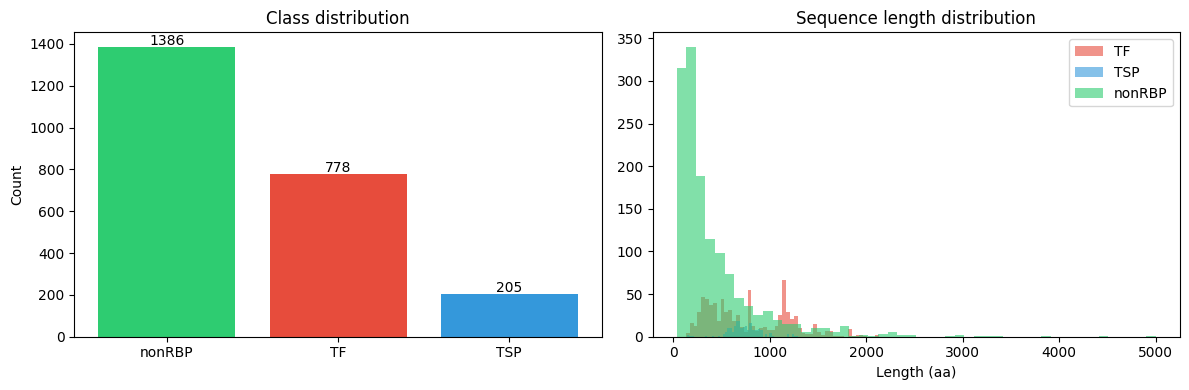

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
TF,778.0,776.9,419.7,129.0,417.2,674.0,1146.2,2129.0
TSP,205.0,736.7,173.2,141.0,644.0,723.0,820.0,1294.0
nonRBP,1386.0,419.5,476.5,34.0,139.0,251.0,505.0,5003.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df["label"].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLORS[l] for l in counts.index])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center")

# Sequence length distribution
for label, grp in df.groupby("label"):
    axes[1].hist(grp["seq_len"], bins=50, alpha=0.6,
                 label=label, color=COLORS[label])
axes[1].set_title("Sequence length distribution")
axes[1].set_xlabel("Length (aa)")
axes[1].legend()
plt.tight_layout()
plt.show()
df.groupby("label")["seq_len"].describe().round(1)

## 2. Cluster-aware Train / Val / Test Split

Run MMseqs2 on all sequences combined at 30% identity. Sequences in the same cluster are forced into the same split to prevent data leakage.

In [21]:
import shutil

def mmseqs_cluster_all(df: pd.DataFrame, min_id: float = 0.3, cov: float = 0.8) -> dict[str, str]:
    """Return {seq_id: cluster_rep} for all sequences."""
    if not shutil.which("mmseqs"):
        raise RuntimeError("mmseqs not in PATH")
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        fasta = tmp / "all.fasta"
        with open(fasta, "w") as f:
            for _, row in df.iterrows():
                f.write(f">{row['id']}\n{row['sequence']}\n")
        prefix = tmp / "clust"
        subprocess.run([
            "mmseqs", "easy-cluster",
            str(fasta), str(prefix), str(tmp / "mmseqs_tmp"),
            "--min-seq-id", str(min_id),
            "-c", str(cov), "--cov-mode", "0",
            "--cluster-mode", "2", "-v", "0",
        ], check=True)
        member_to_rep = {}
        with open(str(prefix) + "_cluster.tsv") as f:
            for line in f:
                rep, member = line.strip().split("\t")
                member_to_rep[member] = rep
    return member_to_rep


def cluster_aware_split(
    df: pd.DataFrame,
    member_to_rep: dict[str, str],
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    df = df.copy()
    df["cluster"] = df["id"].map(member_to_rep)

    # Build cluster-level info: dominant label + size
    clust_info = (
        df.groupby("cluster")["label"]
        .agg(lambda s: s.value_counts().index[0])  # dominant label
        .reset_index()
        .rename(columns={"label": "dominant_label"})
    )
    clust_info["size"] = df.groupby("cluster").size().values

    # Stratified shuffle split at cluster level
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=val_frac + test_frac, random_state=seed
    )
    X = clust_info["cluster"].values
    y = clust_info["dominant_label"].values
    train_idx, holdout_idx = next(sss.split(X, y))

    holdout_info = clust_info.iloc[holdout_idx]
    sss2 = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_frac / (val_frac + test_frac),
        random_state=seed,
    )
    val_idx, test_idx = next(
        sss2.split(holdout_info["cluster"].values, holdout_info["dominant_label"].values)
    )

    train_clusts = set(clust_info.iloc[train_idx]["cluster"])
    val_clusts   = set(holdout_info.iloc[val_idx]["cluster"])
    test_clusts  = set(holdout_info.iloc[test_idx]["cluster"])

    def assign(row):
        c = row["cluster"]
        if c in train_clusts: return "train"
        if c in val_clusts:   return "val"
        return "test"

    df["split"] = df.apply(assign, axis=1)
    return df


print("Running MMseqs2 clustering on all sequences...")
member_to_rep = mmseqs_cluster_all(df, min_id=CLUST_ID)
df = cluster_aware_split(df, member_to_rep, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED)

print("\nSplit counts:")
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))

Running MMseqs2 clustering on all sequences...

Split counts:
label   TF  TSP  nonRBP
split                  
test    78   28     208
train  601  155     970
val     99   22     208


## 3. Extract ESMC Embeddings

Mean-pool over residue positions (excluding BOS/EOS tokens). Embeddings are cached to disk — skip extraction if cache exists.

In [22]:
# Requires: huggingface-cli login (accept license at huggingface.co/biohub/ESMC-6B)
# low_cpu_mem_usage=False avoids accelerate meta-device dispatch bug with inv_freq buffers
esmc_model = AutoModelForMaskedLM.from_pretrained(
    ESMC_MODEL_NAME,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=False,
).to(DEVICE).eval()
esmc_tokenizer = AutoTokenizer.from_pretrained(ESMC_MODEL_NAME)

embed_dim = esmc_model.config.d_model  # ESMCConfig uses d_model, not hidden_size
print(f"Loaded {ESMC_MODEL_NAME}")
print(f"Embedding dim: {embed_dim}")

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded biohub/ESMC-6B
Embedding dim: 2560


In [23]:
@torch.inference_mode()
def embed_sequence(sequence: str) -> np.ndarray:
    inputs = esmc_tokenizer([sequence], return_tensors="pt", padding=False)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    output = esmc_model(**inputs, output_hidden_states=True)
    # hidden_states[-1]: (1, L+2, d) — BOS at 0, EOS at -1
    emb = output.hidden_states[-1][0, 1:-1, :].float()
    return emb.mean(dim=0).cpu().numpy()


if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE}")
    cache  = torch.load(EMBED_CACHE, weights_only=True)
    id2emb = dict(zip(cache["ids"], cache["embeddings"]))
else:
    print(f"Extracting embeddings for {len(df)} sequences...")
    ids, embeddings = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        ids.append(row["id"])
        embeddings.append(embed_sequence(row["sequence"]))
    embeddings_np = np.stack(embeddings)
    torch.save({"ids": ids, "embeddings": embeddings_np}, EMBED_CACHE)
    id2emb = dict(zip(ids, embeddings_np))
    print(f"Saved to {EMBED_CACHE}")

df["embedding"] = df["id"].map(id2emb)
print(f"Embedding shape: {df['embedding'].iloc[0].shape}")

Extracting embeddings for 2369 sequences...


  0%|          | 0/2369 [00:00<?, ?it/s]

Saved to ../data/embeddings_cache.pt
Embedding shape: (2560,)


## 4. PCA Exploration

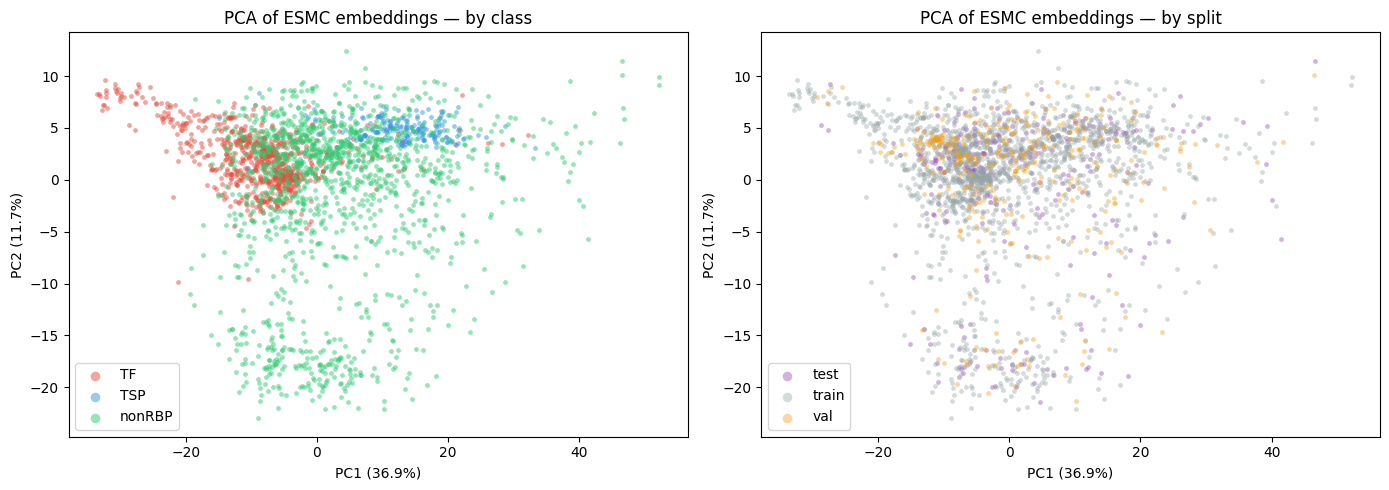

In [24]:
X_all = np.stack(df["embedding"].values)
pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_all)
var   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2, colored by class
for label, grp in df.groupby("label"):
    idx = grp.index
    axes[0].scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=COLORS[label], label=label, alpha=0.5, s=12, linewidths=0,
    )
axes[0].set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
axes[0].set_title("PCA of ESMC embeddings — by class")
axes[0].legend(markerscale=2)

# Same plot colored by split
split_colors = {"train": "#95a5a6", "val": "#f39c12", "test": "#8e44ad"}
for split, grp in df.groupby("split"):
    idx = grp.index
    axes[1].scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=split_colors[split], label=split, alpha=0.4, s=12, linewidths=0,
    )
axes[1].set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
axes[1].set_title("PCA of ESMC embeddings — by split")
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig(DATA_DIR / "pca_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Dataset & DataLoader

In [25]:
class EmbeddingDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.X = torch.tensor(np.stack(df["embedding"].values), dtype=torch.float32)
        self.y = torch.tensor(df["label_id"].values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_ds = EmbeddingDataset(df[df["split"] == "train"])
val_ds   = EmbeddingDataset(df[df["split"] == "val"])
test_ds  = EmbeddingDataset(df[df["split"] == "test"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

# Class weights to handle imbalance
train_labels = df[df["split"] == "train"]["label_id"].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(LABEL2ID)),
    y=train_labels,
)
print(f"Class weights: { {ID2LABEL[i]: round(w, 3) for i, w in enumerate(class_weights)} }")

Train: 1726  Val: 329  Test: 314
Class weights: {'TF': np.float64(0.957), 'TSP': np.float64(3.712), 'nonRBP': np.float64(0.593)}


## 6. Model — Linear Classifier

In [26]:
class LinearClassifier(nn.Module):
    def __init__(self, in_dim: int, n_classes: int):
        super().__init__()
        self.head = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        return self.head(x)


model = LinearClassifier(in_dim=embed_dim, n_classes=len(LABEL2ID)).to(DEVICE)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print(model)

LinearClassifier(
  (head): Linear(in_features=2560, out_features=3, bias=True)
)


## 7. Training

In [27]:
def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss   = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(val_loader,   model, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.3f} | "
              f"vl_loss {vl_loss:.4f} vl_acc {vl_acc:.3f}")

print(f"\nBest val acc: {best_val_acc:.3f}")
model.load_state_dict(best_state)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  10 | tr_loss 0.0368 tr_acc 0.991 | vl_loss 0.0758 vl_acc 0.982
Epoch  20 | tr_loss 0.0212 tr_acc 0.993 | vl_loss 0.0642 vl_acc 0.982
Epoch  30 | tr_loss 0.0165 tr_acc 0.995 | vl_loss 0.0613 vl_acc 0.985
Epoch  40 | tr_loss 0.0133 tr_acc 0.996 | vl_loss 0.0602 vl_acc 0.985
Epoch  50 | tr_loss 0.0131 tr_acc 0.996 | vl_loss 0.0600 vl_acc 0.985

Best val acc: 0.985


<All keys matched successfully>

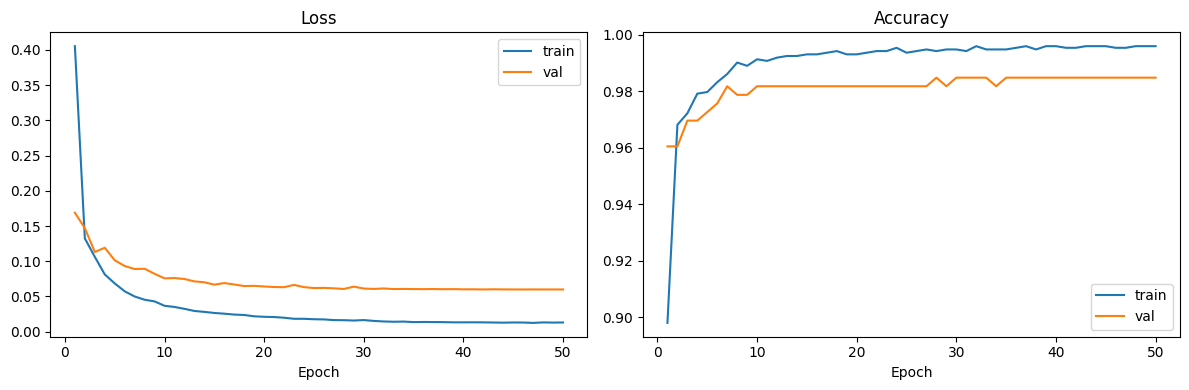

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Evaluation on Test Set

              precision    recall  f1-score   support

          TF       0.99      0.97      0.98        78
         TSP       1.00      0.93      0.96        28
      nonRBP       0.98      1.00      0.99       208

    accuracy                           0.98       314
   macro avg       0.99      0.97      0.98       314
weighted avg       0.98      0.98      0.98       314



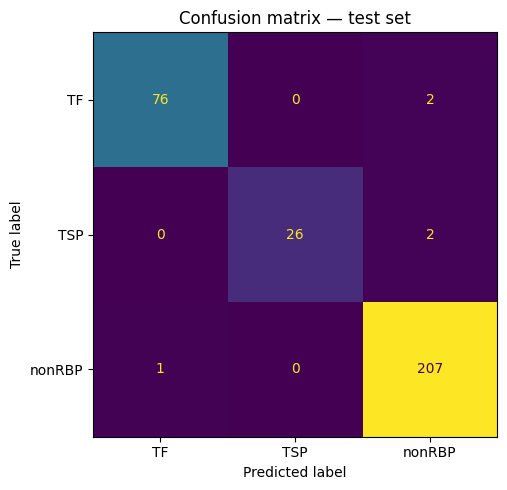

In [29]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        preds = model(X.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

label_names = [ID2LABEL[i] for i in range(len(LABEL2ID))]
print(classification_report(all_labels, all_preds, target_names=label_names))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, colorbar=False)
ax.set_title("Confusion matrix — test set")
plt.tight_layout(); plt.show()

## 9. Save Model

In [31]:
checkpoint = {
    "model_state_dict": best_state,
    "label2id": LABEL2ID,
    "id2label": ID2LABEL,
    "embed_dim": embed_dim,
    "esmc_model_name": ESMC_MODEL_NAME,
    "best_val_acc": best_val_acc,
}
save_path = MODELS_DIR / f"rbpdetect2_linear_{ESMC_MODEL_NAME}.pt"
torch.save(checkpoint, save_path)
print(f"Saved to {save_path}")

Saved to ../models/rbpdetect2_linear_biohub/ESMC-6B.pt
